In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score


In [2]:
df=pd.read_csv("cleaned_carbon_data.csv")
df.sample()

,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
8776,underweight,male,vegan,more frequently,coal,walk/bicycle,No Vehicle,sometimes,83,very frequently,25,small,1,3,15,0,Sometimes,"['Paper', 'Plastic', 'Glass']",['Stove'],1856


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9545 entries, 0 to 9544
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Body Type                      9545 non-null   object
 1   Sex                            9545 non-null   object
 2   Diet                           9545 non-null   object
 3   How Often Shower               9545 non-null   object
 4   Heating Energy Source          9545 non-null   object
 5   Transport                      9545 non-null   object
 6   Vehicle Type                   9545 non-null   object
 7   Social Activity                9545 non-null   object
 8   Monthly Grocery Bill           9545 non-null   int64 
 9   Frequency of Traveling by Air  9545 non-null   object
 10  Vehicle Monthly Distance Km    9545 non-null   int64 
 11  Waste Bag Size                 9545 non-null   object
 12  Waste Bag Weekly Count         9545 non-null   int64 
 13  How

In [4]:
df["Vehicle Type"] = df["Vehicle Type"].fillna("No Vehicle")

In [5]:
df["CarbonEmission"].skew()

np.float64(0.5445210284127474)

<Axes: xlabel='CarbonEmission'>

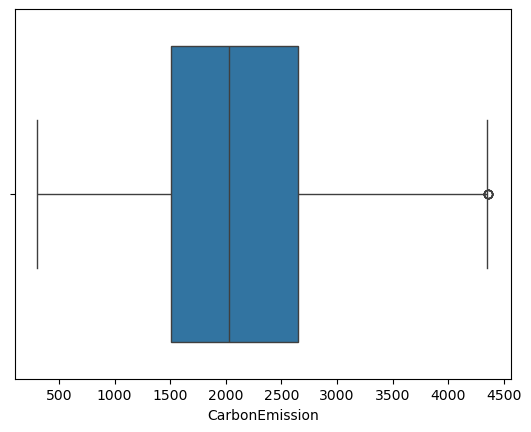

In [6]:
sns.boxplot(x=df["CarbonEmission"])

In [7]:
Q1 = df["CarbonEmission"].quantile(0.25)
Q3 = df["CarbonEmission"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [8]:
df = df[(df["CarbonEmission"] >= lower_bound) & (df["CarbonEmission"] <= upper_bound)]

In [9]:
df.to_csv("cleaned_carbon_data.csv", index=False)

In [10]:
df["CarbonEmission"].skew()

np.float64(0.5398920519629359)

<Axes: xlabel='CarbonEmission'>

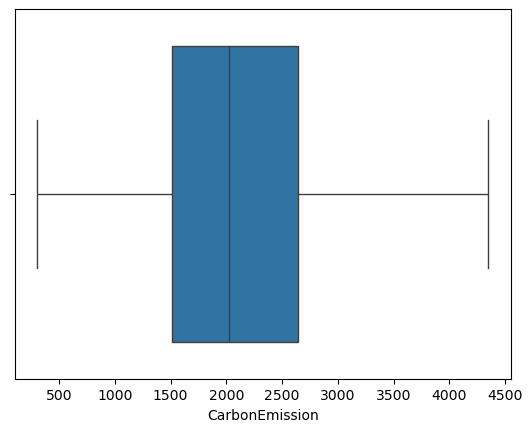

In [11]:
sns.boxplot(x=df["CarbonEmission"])

In [12]:
X = df.drop("CarbonEmission", axis=1)
y = df["CarbonEmission"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(include=["int64"]).columns

In [15]:
ordinal_mapping = {
    "How Often Shower": ["less frequently", "daily", "more frequently", "twice a day"],
    "Social Activity": ["never", "sometimes", "often"],
    "Frequency of Traveling by Air": ["never", "rarely", "frequently", "very frequently"],
    "Waste Bag Size": ["small", "medium", "large", "extra large"],
    "Energy efficiency": ["No", "Sometimes", "Yes"]
}

ordinal_cols = list(ordinal_mapping.keys())
nominal_cols = [col for col in cat_cols if col not in ordinal_cols]

In [16]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [17]:
ordinal_categories = [ordinal_mapping[col] for col in ordinal_cols]

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=ordinal_categories))
])

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols),
        ("ord", ordinal_pipeline, ordinal_cols),
        ("nom", nominal_pipeline, nominal_cols)
    ]
)

In [19]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [20]:
linear_pipeline.fit(X_train,y_train)
rf_pipeline.fit(X_train,y_train)

y_pred_lr = linear_pipeline.predict(X_test)

y_pred_rf = rf_pipeline.predict(X_test)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Train R2": [
        r2_score(y_train, linear_pipeline.predict(X_train)),
        r2_score(y_train, rf_pipeline.predict(X_train))
    ],
    "Test R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ],
    "Train RMSE": [
        np.sqrt(mean_squared_error(y_train, linear_pipeline.predict(X_train))),
        np.sqrt(mean_squared_error(y_train, rf_pipeline.predict(X_train)))
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ]
    
})

results

,Model,Train R2,Test R2,Train RMSE,Test RMSE
0,Linear Regression,0.905789,0.905887,249.372392,252.479563
1,Random Forest,0.985348,0.903875,98.342388,255.163857


In [21]:
import joblib
joblib.dump(linear_pipeline, "linear_regression_model.pkl")

['linear_regression_model.pkl']